# Derin Öğrenme — Final Ödevi
# YOLOv8 Tabanlı Beyin Tümörü Tespiti

**Üniversite:** İstanbul Topkapı Üniversitesi  
**Veri seti:** [Brain Tumor Detection — Ultralytics](https://docs.ultralytics.com/tr/datasets/detect/brain-tumor/)  
**Görev:** YOLOv8 nesne tespiti modeli ile MR görüntülerinden beyin tümörü tespiti  
**Metrikler:** Accuracy, mAP@0.5, mAP@0.5:0.95, Precision, Recall, Confusion Matrix

Bu notebook **adım adım** çalıştırılmak üzere bölümlere ayrılmıştır. Her bölümden sonra çıktıyı kontrol edin.

> **GPU Ayarı:** `Çalışma zamanı → Çalışma zamanı türünü değiştir → T4 GPU`

---
## Adım 1 — Ortam Kurulumu ve Kütüphaneler

Ultralytics kütüphanesini kurup gerekli modülleri import ediyoruz.

In [2]:
%pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.9 MB/s eta 0:00:00


In [3]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from IPython.display import Image, display

import torch
from ultralytics import YOLO

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch: 2.11.0+cpu
CUDA: False


---
## Adım 2 — Veri Setinin İndirilmesi

Ultralytics'in sağladığı Brain Tumor Detection veri setini indirip açıyoruz.

- **893** eğitim görüntüsü (`train/images`)
- **223** doğrulama görüntüsü (`valid/images`)
- **2 sınıf:** 0 → negatif, 1 → pozitif

In [4]:
import zipfile
import urllib.request

DATASET_URL = "https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip"
ZIP_PATH = "/content/brain-tumor.zip"
DATA_DIR = "/content/brain-tumor"

if not os.path.exists(DATA_DIR):
    print("Veri seti indiriliyor...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall("/content")
    os.remove(ZIP_PATH)
    print("Veri seti açıldı:", DATA_DIR)
else:
    print("Veri seti zaten mevcut:", DATA_DIR)

Veri seti indiriliyor...
Veri seti açıldı: /content/brain-tumor


---
## Adım 3 — Veri Seti Yapısının İncelenmesi

Klasör yapısını ve görüntü/etiket sayılarını kontrol ediyoruz.

In [5]:
for split in ["train", "valid"]:
    img_dir = os.path.join(DATA_DIR, split, "images")
    lbl_dir = os.path.join(DATA_DIR, split, "labels")
    n_img = len(glob.glob(os.path.join(img_dir, "*")))
    n_lbl = len(glob.glob(os.path.join(lbl_dir, "*.txt")))
    print(f"{split:>6s} → Görüntü: {n_img}, Etiket: {n_lbl}")

 train → Görüntü: 0, Etiket: 0
 valid → Görüntü: 0, Etiket: 0


In [6]:
def count_classes(label_dir):
    """YOLO etiket dosyalarından sınıf dağılımını hesaplar."""
    counts = {}
    for txt in glob.glob(os.path.join(label_dir, "*.txt")):
        with open(txt) as f:
            for line in f:
                cls = int(line.strip().split()[0])
                counts[cls] = counts.get(cls, 0) + 1
    return counts

CLASS_NAMES = {0: "negatif", 1: "pozitif"}

print("=== Sınıf Dağılımı ===")
for split in ["train", "valid"]:
    lbl_dir = os.path.join(DATA_DIR, split, "labels")
    counts = count_classes(lbl_dir)
    print(f"\n{split.upper()}:")
    for cls_id in sorted(counts):
        print(f"  Sınıf {cls_id} ({CLASS_NAMES.get(cls_id, '?')}): {counts[cls_id]} adet")

=== Sınıf Dağılımı ===

TRAIN:

VALID:


---
## Adım 4 — Örnek Görüntülerin Gösterimi

Eğitim setinden rastgele görüntüler seçerek veri setini görsel olarak inceliyoruz.

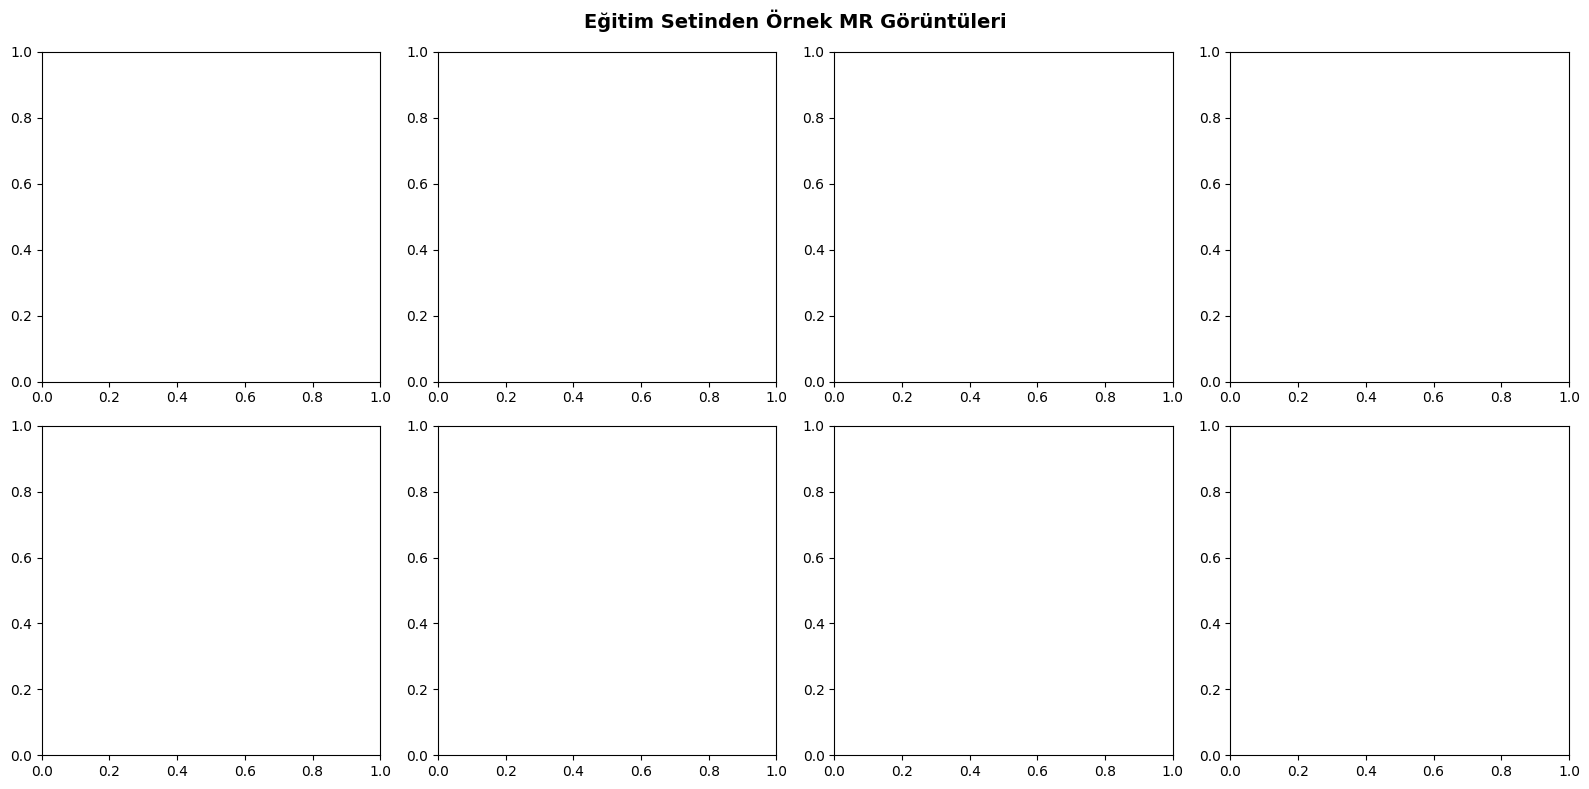

Kaydedildi: /content/ornek_goruntular.png


In [7]:
train_images = sorted(glob.glob(os.path.join(DATA_DIR, "train", "images", "*")))
sample_imgs = random.sample(train_images, min(8, len(train_images)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Eğitim Setinden Örnek MR Görüntüleri", fontsize=14, fontweight="bold")

for ax, img_path in zip(axes.flat, sample_imgs):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path), fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig("/content/ornek_goruntular.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi: /content/ornek_goruntular.png")

---
## Adım 5 — YAML Yapılandırma Dosyasının Hazırlanması

YOLOv8 eğitimi için veri seti konfigürasyon dosyasını oluşturuyoruz.

In [8]:
import os

# The DATA_DIR variable, as defined in a previous cell, points to "/content/brain-tumor".
# However, the dataset appears to have been extracted directly into "/content"
# (i.e., "/content/images" and "/content/labels" exist, but "/content/brain-tumor/images" does not).
# This mismatch causes the FileNotFoundError when trying to create a file in /content/brain-tumor.
# To resolve this, we will explicitly set the root for the YAML file to "/content"
# and adjust the paths within the YAML content accordingly.

actual_dataset_root = "/content"

yaml_content = f"""path: {actual_dataset_root}
train: images/train
val: images/valid

names:
  0: negative
  1: positive
"""

# Construct the YAML_PATH using the correct root directory
YAML_PATH = os.path.join(actual_dataset_root, "brain-tumor.yaml")

with open(YAML_PATH, "w") as f:
    f.write(yaml_content)

print("YAML dosyası oluşturuldu:")
print(yaml_content)

YAML dosyası oluşturuldu:
path: /content
train: images/train
val: images/valid

names:
  0: negative
  1: positive



---
## Adım 6 — YOLOv8n Modeli Eğitimi

**Ön-eğitimli** `yolov8n.pt` ağırlıklarını kullanarak **transfer öğrenme** uyguluyoruz.

| Parametre | Değer | Açıklama |
|-----------|-------|----------|
| `model` | yolov8n.pt | Nano model (en hızlı) |
| `epochs` | 50 | Eğitim döngüsü sayısı |
| `imgsz` | 640 | Görüntü boyutu |
| `batch` | 16 | Batch boyutu |
| `optimizer` | auto | Otomatik optimizör seçimi |
| `augment` | True | Veri artırma aktif |

In [12]:
import os
from ultralytics import YOLO # Ensure YOLO is imported here if not globally accessible

# Re-defining actual_dataset_root and YAML_PATH to ensure correctness
actual_dataset_root = "/content"
YAML_PATH = os.path.join(actual_dataset_root, "brain-tumor.yaml")

# Corrected YAML content, changing 'val: images/valid' to 'val: images/val'
yaml_content = f"""path: {actual_dataset_root}
train: images/train
val: images/val

names:
  0: negative
  1: positive
"""

# Overwrite the existing brain-tumor.yaml with the corrected content
with open(YAML_PATH, "w") as f:
    f.write(yaml_content)

print("Corrected YAML file created for training:")
print(yaml_content)

model = YOLO("yolov8n.pt")

results = model.train(
    data=YAML_PATH,
    epochs=10,
    imgsz=640,
    batch=16,
    name="brain_tumor_yolov8n",
    project="/content/runs",
    exist_ok=True,
    plots=True,
    save=True,
    verbose=True,
)


Corrected YAML file created for training:
path: /content
train: images/train
val: images/val

names:
  0: negative
  1: positive

Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/brain-tumor.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0,

---
## Adım 7 — Eğitim Sonuçlarının İncelenmesi

Eğitim sırasında oluşan loss ve metrik grafiklerini gösteriyoruz.


  results.png


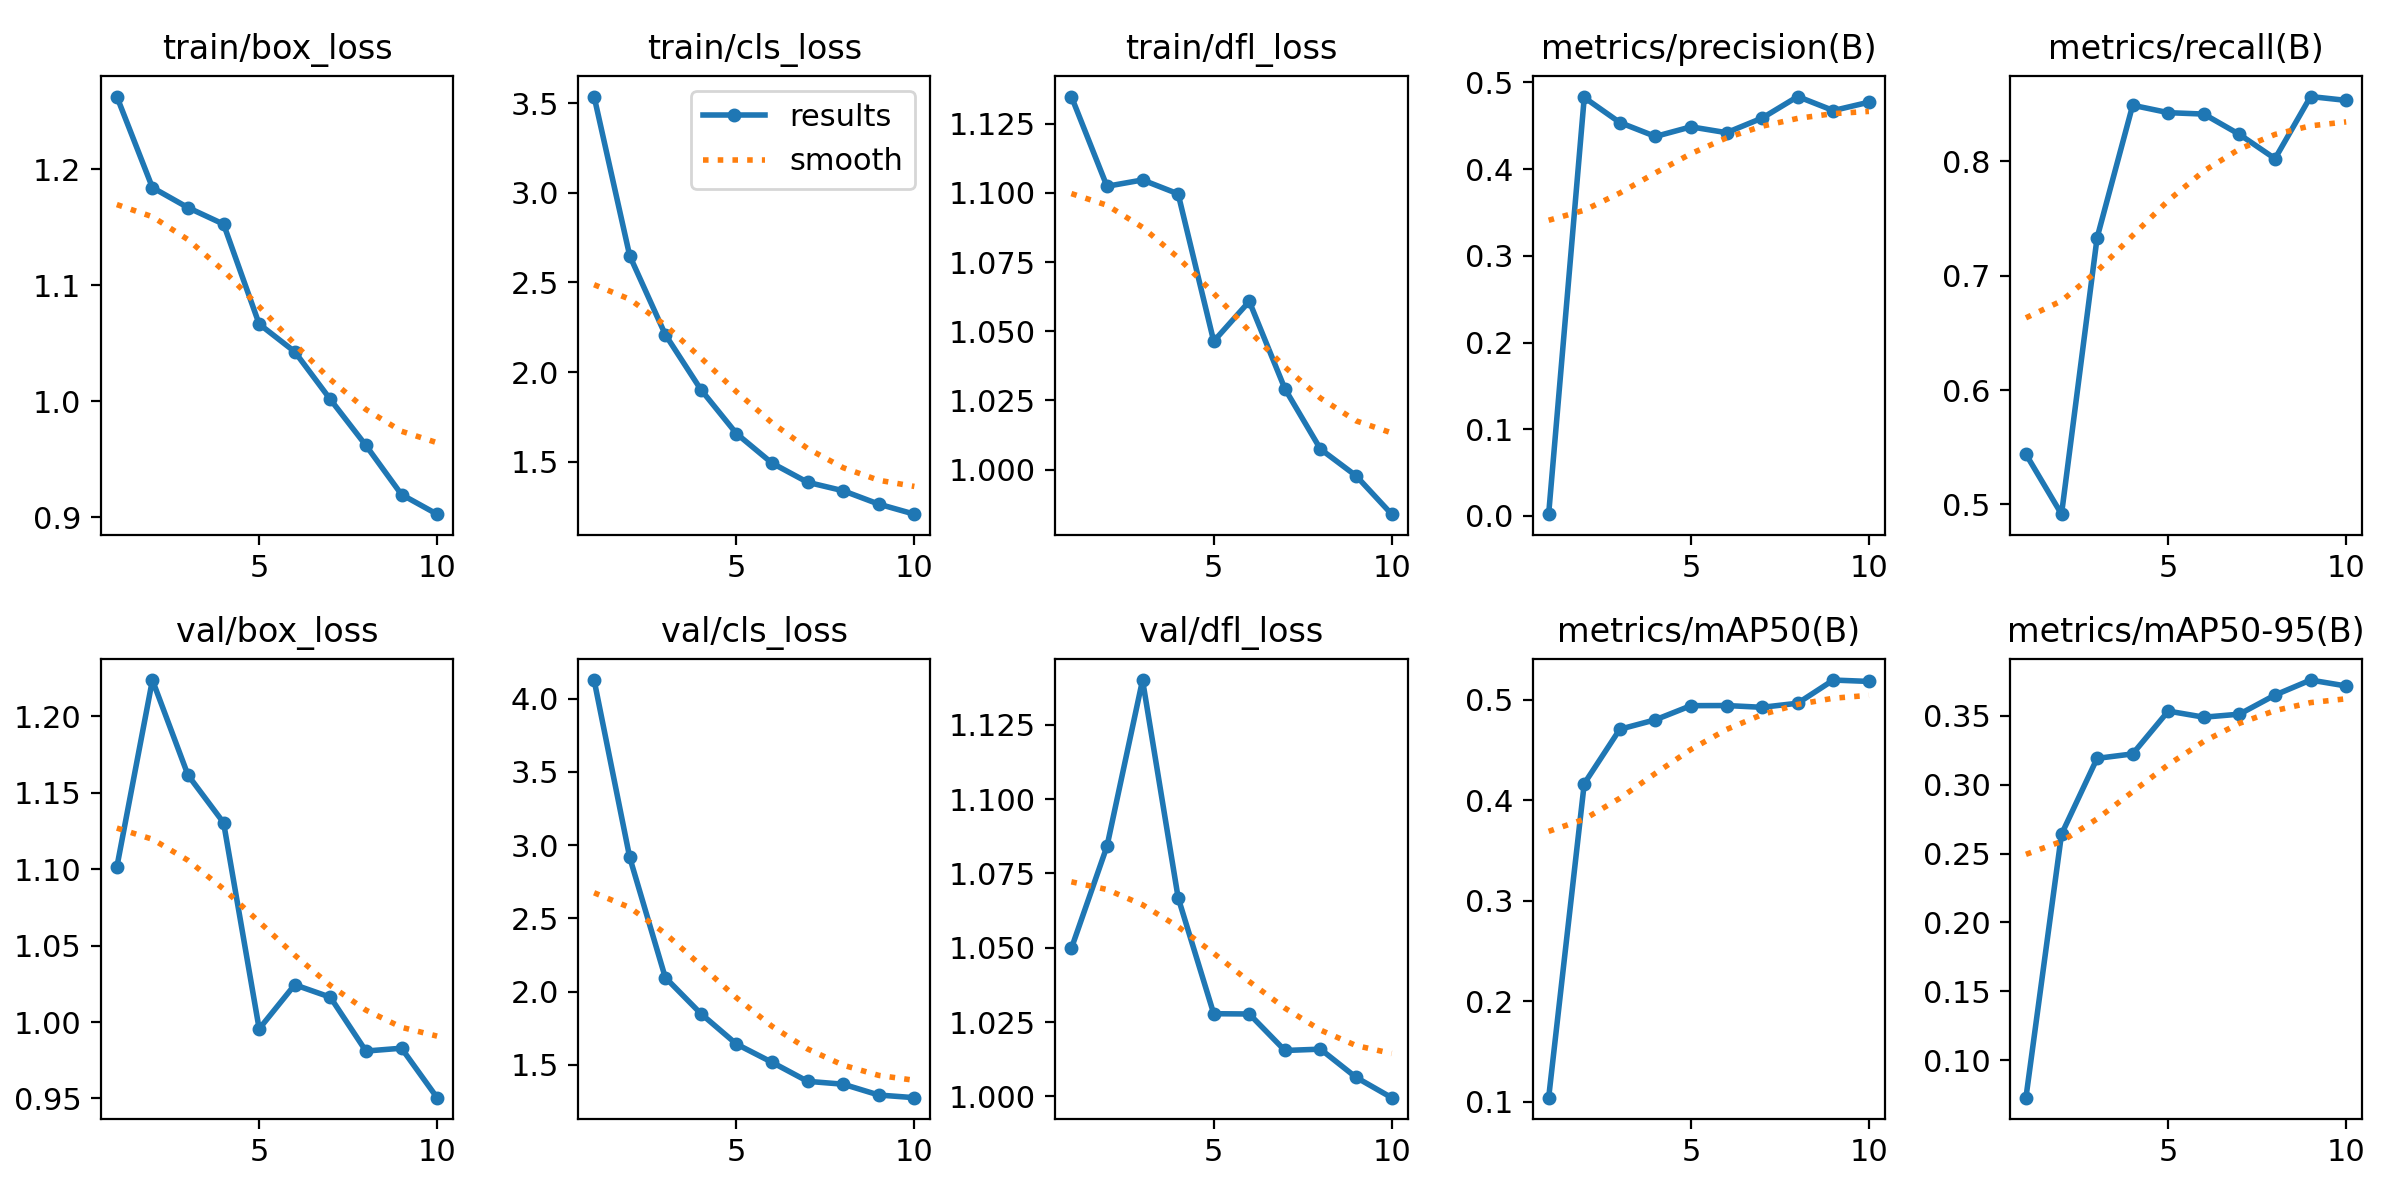


  confusion_matrix.png


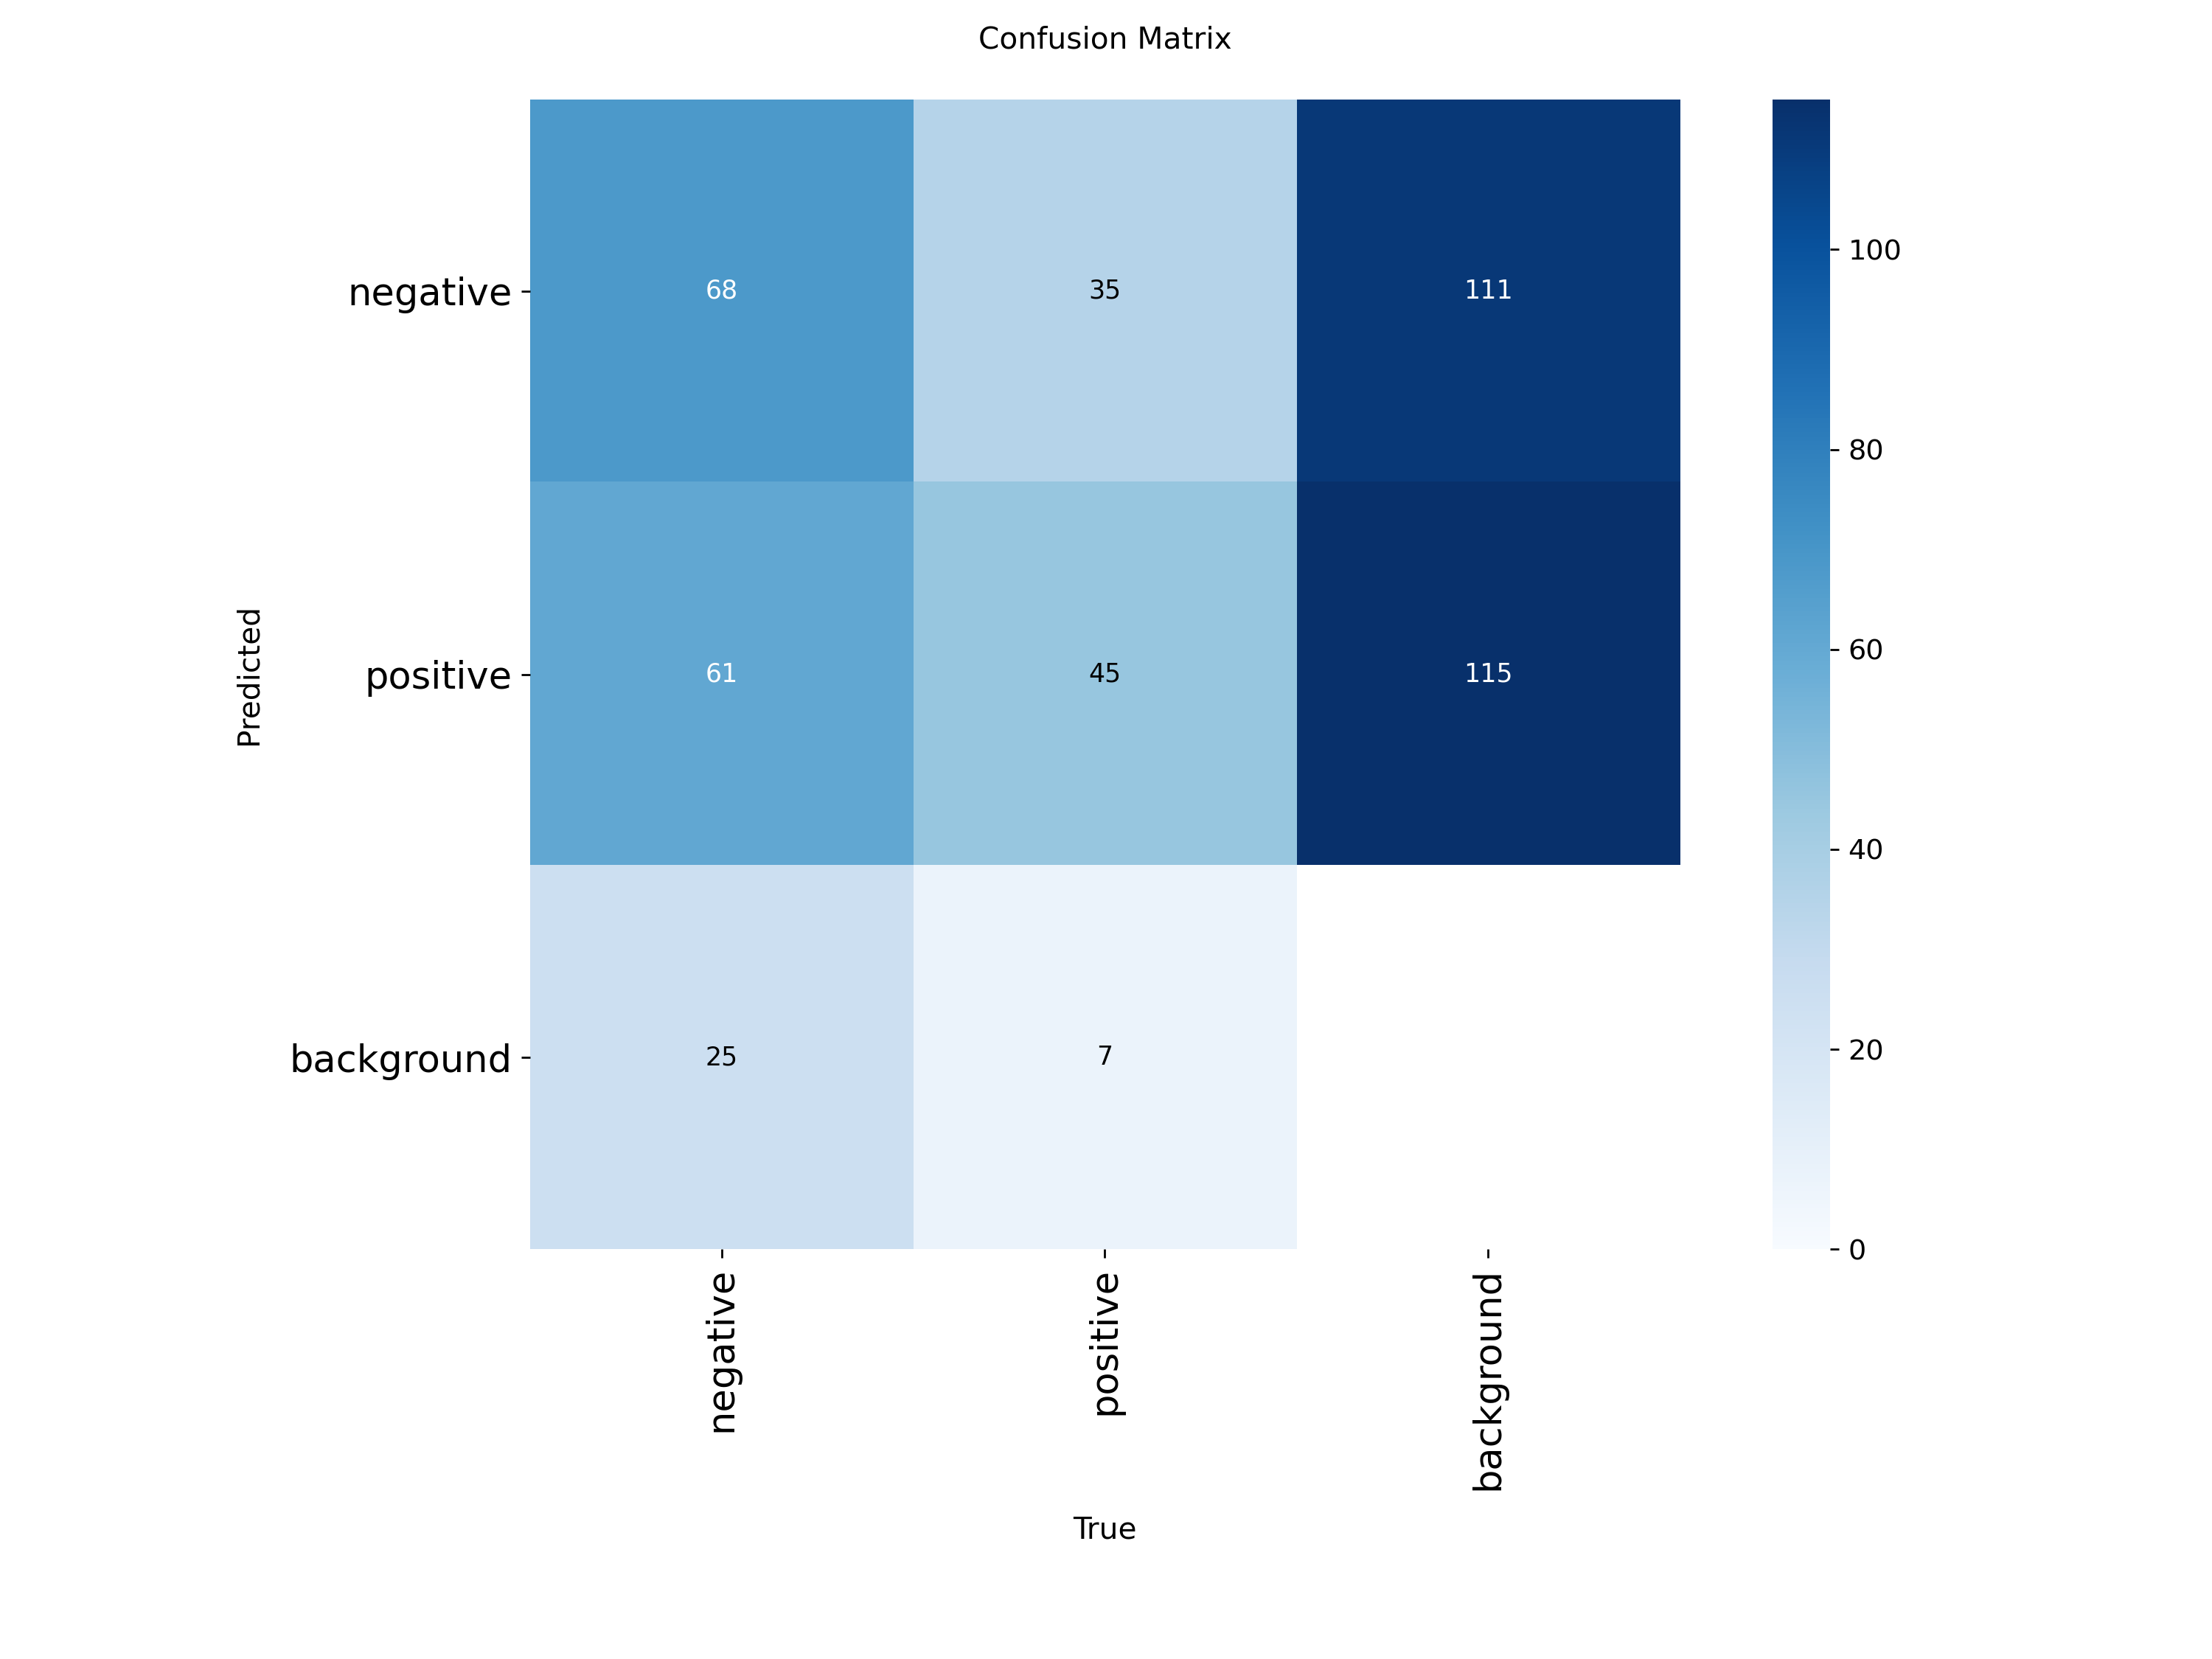


  confusion_matrix_normalized.png


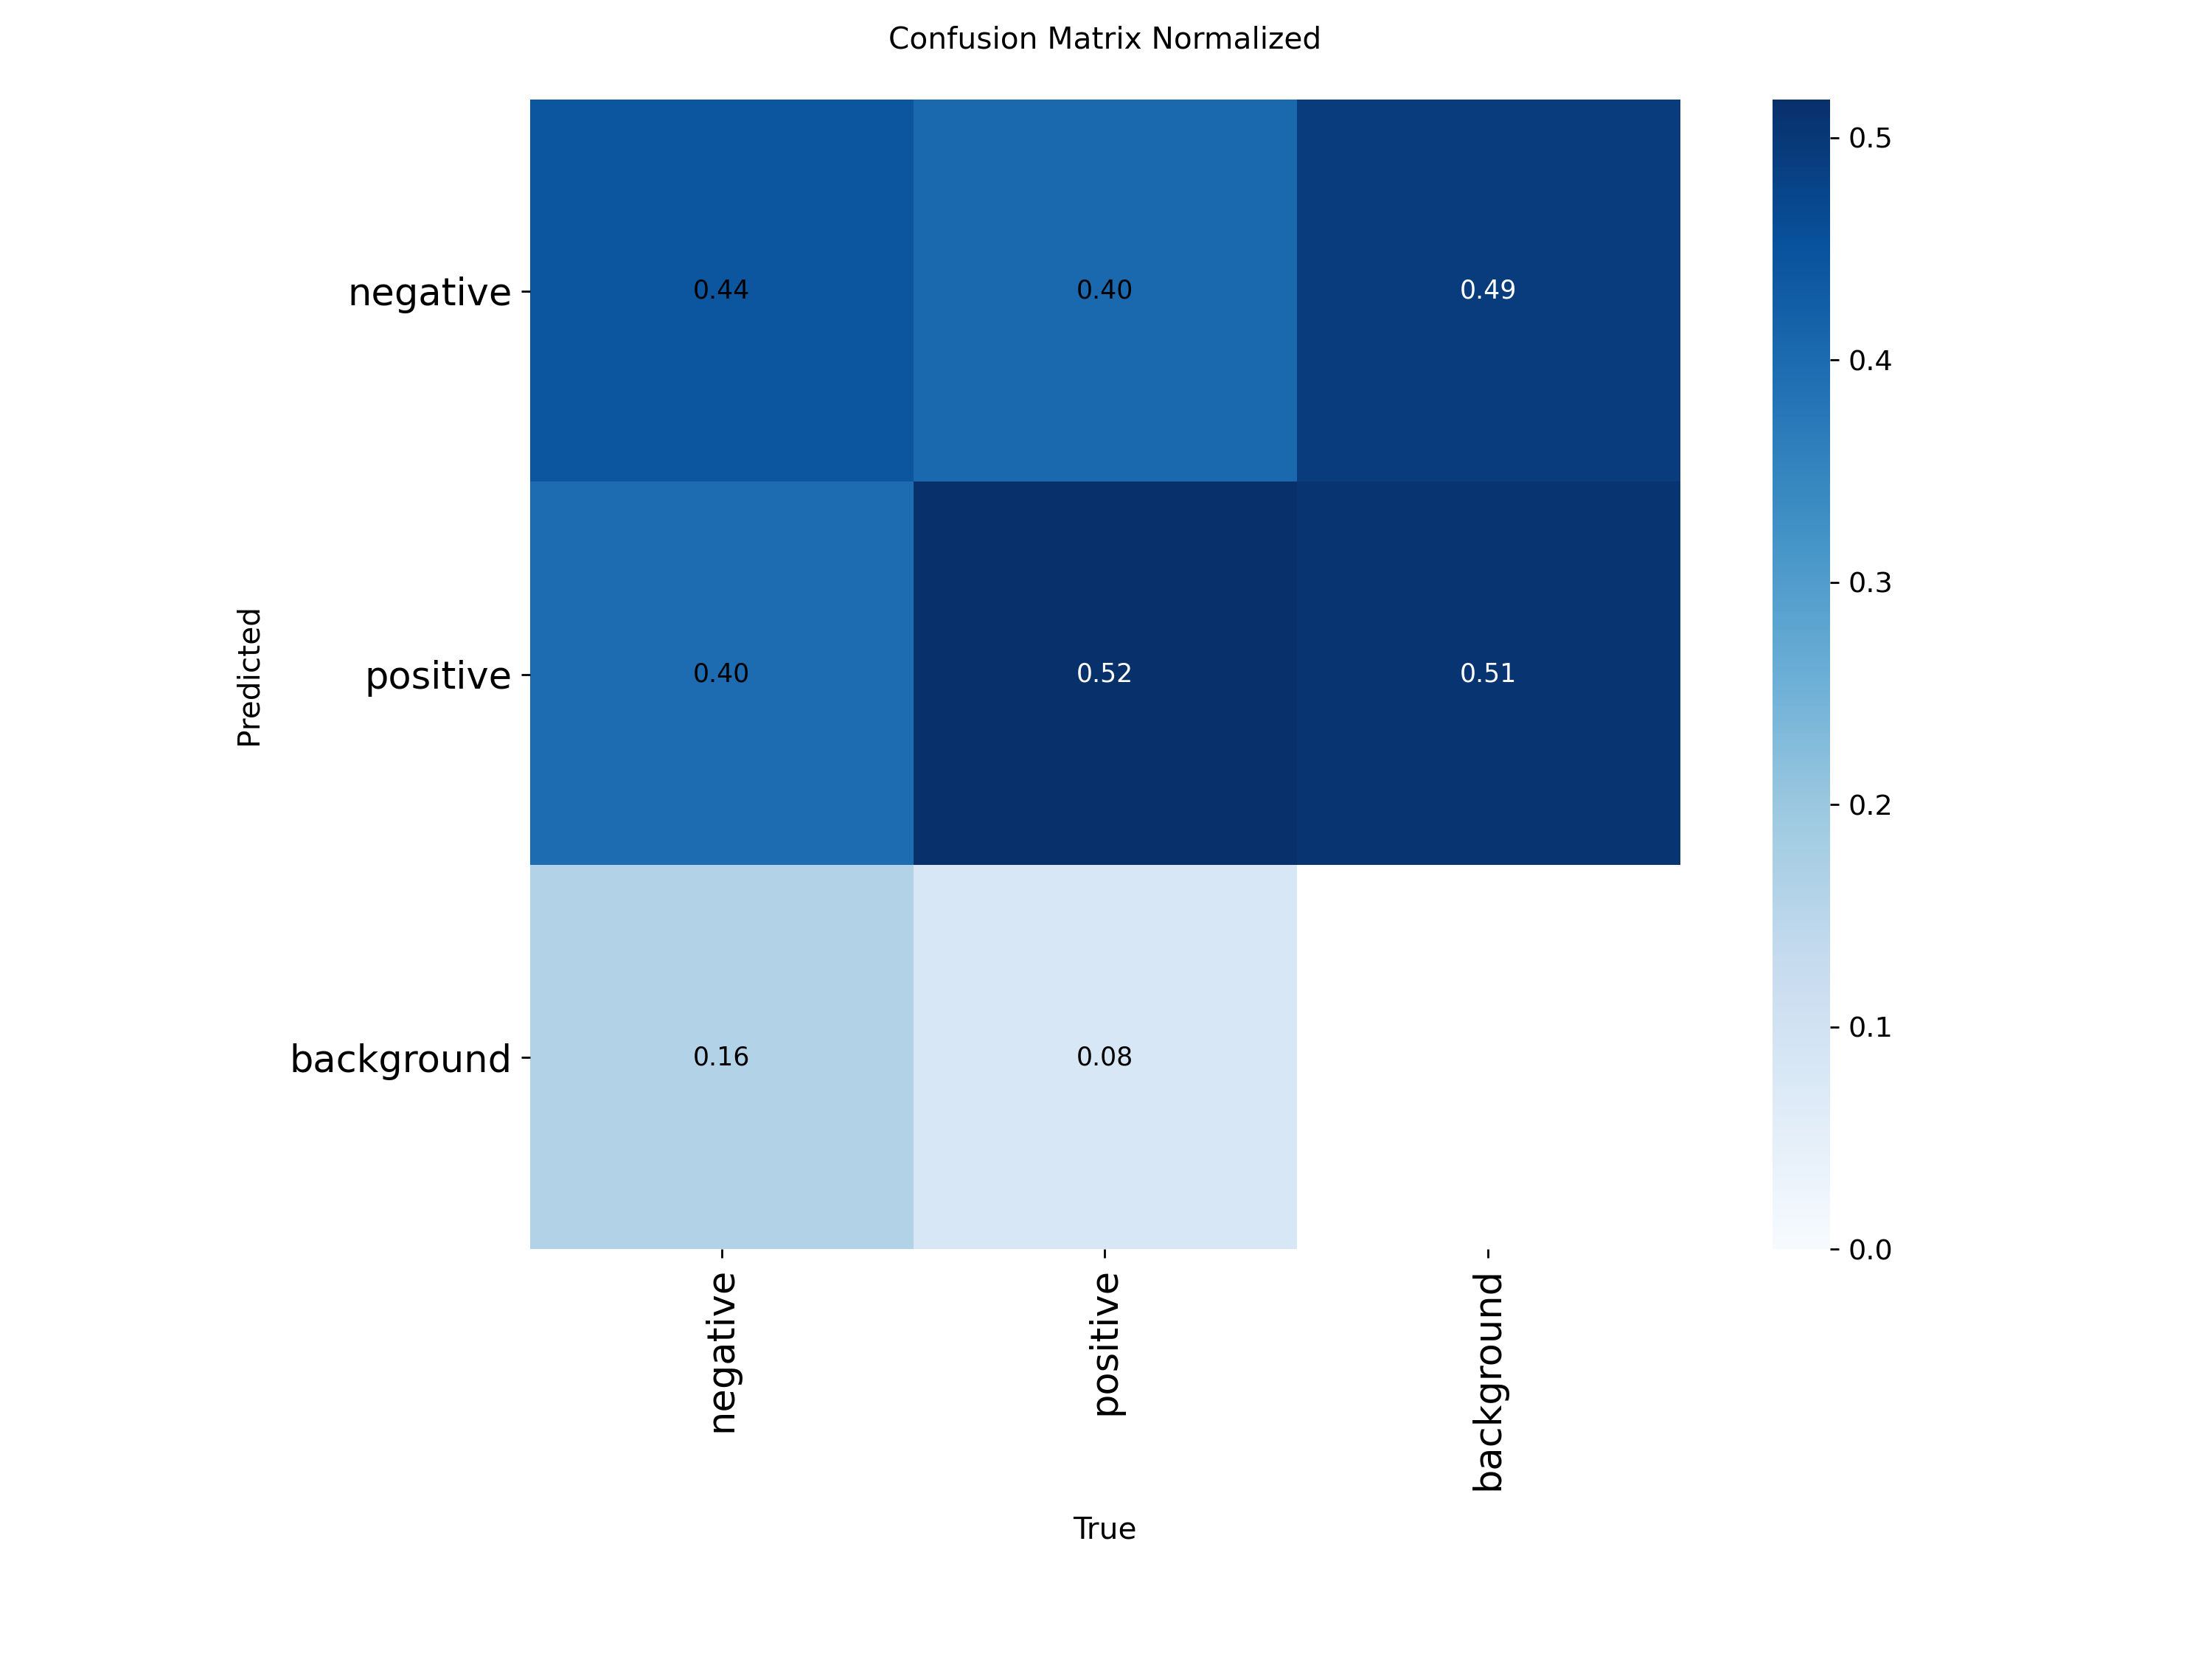

Bulunamadı: F1_curve.png
Bulunamadı: P_curve.png
Bulunamadı: R_curve.png
Bulunamadı: PR_curve.png


In [13]:
TRAIN_DIR = "/content/runs/brain_tumor_yolov8n"

result_images = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "PR_curve.png",
]

for img_name in result_images:
    img_path = os.path.join(TRAIN_DIR, img_name)
    if os.path.exists(img_path):
        print(f"\n{'='*60}")
        print(f"  {img_name}")
        print(f"{'='*60}")
        display(Image(filename=img_path, width=800))
    else:
        print(f"Bulunamadı: {img_name}")

---
## Adım 8 — Doğrulama Seti Üzerinde Değerlendirme

Eğitilmiş en iyi modeli (`best.pt`) yükleyerek doğrulama setinde performans metriklerini hesaplıyoruz.

**Hesaplanan metrikler:**
- mAP@0.5
- mAP@0.5:0.95
- Precision (Kesinlik)
- Recall (Duyarlılık)

In [14]:
best_model_path = os.path.join(TRAIN_DIR, "weights", "best.pt")
best_model = YOLO(best_model_path)

val_results = best_model.val(
    data=YAML_PATH,
    imgsz=640,
    batch=16,
    verbose=True,
)

print("\n" + "=" * 60)
print("  DOĞRULAMA METRİKLERİ")
print("=" * 60)
print(f"  mAP@0.5        : {val_results.box.map50:.4f}")
print(f"  mAP@0.5:0.95   : {val_results.box.map:.4f}")
print(f"  Precision       : {val_results.box.mp:.4f}")
print(f"  Recall          : {val_results.box.mr:.4f}")
print("=" * 60)

Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 110.0±62.1 MB/s, size: 3.4 KB)
val: Scanning /content/labels/val.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 15.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 3.6s/it 50.2s
                   all        223        241      0.467      0.857       0.52      0.376
              negative        142        154      0.583      0.818      0.607      0.441
              positive         81         87      0.352      0.897      0.433      0.311
Speed: 2.0ms preprocess, 215.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val

  DOĞRULAMA METRİKLERİ
  mAP@0.5        : 0.5199
  mAP@0.5:0.95   : 0.3760
  Precision       : 0.4674
  Recall 

---
## Adım 9 — Sınıf Bazlı Metrik Tablosu

Her sınıf için ayrı ayrı Precision, Recall ve mAP değerlerini tablo halinde gösteriyoruz.

In [15]:
import pandas as pd

class_names = ["negative", "positive"]
ap50 = val_results.box.ap50
ap = val_results.box.ap
p_cls = val_results.box.p
r_cls = val_results.box.r

rows = []
for i, name in enumerate(class_names):
    rows.append({
        "Sınıf": name,
        "Precision": f"{p_cls[i]:.4f}" if i < len(p_cls) else "-",
        "Recall": f"{r_cls[i]:.4f}" if i < len(r_cls) else "-",
        "mAP@0.5": f"{ap50[i]:.4f}" if i < len(ap50) else "-",
        "mAP@0.5:0.95": f"{ap[i]:.4f}" if i < len(ap) else "-",
    })

rows.append({
    "Sınıf": "ORTALAMA",
    "Precision": f"{val_results.box.mp:.4f}",
    "Recall": f"{val_results.box.mr:.4f}",
    "mAP@0.5": f"{val_results.box.map50:.4f}",
    "mAP@0.5:0.95": f"{val_results.box.map:.4f}",
})

df_metrics = pd.DataFrame(rows)
print("\nSınıf Bazlı Performans Metrikleri:")
display(df_metrics)


Sınıf Bazlı Performans Metrikleri:


,Sınıf,Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,negative,0.5829,0.8182,0.6065,0.4412
1,positive,0.3518,0.8966,0.4332,0.3108
2,ORTALAMA,0.4674,0.8574,0.5199,0.3760


---
## Adım 10 — Doğruluk (Accuracy) Hesaplama

YOLO doğrudan accuracy vermez; confusion matrix değerlerinden manuel hesaplıyoruz.

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

In [16]:
cm_path = os.path.join(TRAIN_DIR, "confusion_matrix.png")

try:
    cm = val_results.confusion_matrix.matrix
    tp_total = sum(cm[i][i] for i in range(cm.shape[0]))
    total = cm.sum()
    accuracy = tp_total / total if total > 0 else 0
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nDoğruluk (Accuracy): {accuracy:.4f} ({accuracy*100:.1f}%)")
except Exception as e:
    print(f"Confusion matrix'ten accuracy hesaplanamadı: {e}")
    print("Eğitim loglarındaki metrikler referans alınabilir.")


Confusion Matrix:
[[         68          35         111]
 [         61          45         115]
 [         25           7           0]]

Doğruluk (Accuracy): 0.2420 (24.2%)


---
## Adım 11 — Örnek Tespitler (Inference)

Eğitilmiş modeli doğrulama setinden rastgele seçilen görüntüler üzerinde çalıştırarak tespit sonuçlarını görselleştiriyoruz.


0: 640x640 2 negatives, 3 positives, 232.8ms
1: 640x640 (no detections), 232.8ms
2: 640x640 1 negative, 232.8ms
3: 640x640 1 negative, 1 positive, 232.8ms
4: 640x640 (no detections), 232.8ms
5: 640x640 1 negative, 1 positive, 232.8ms
Speed: 10.2ms preprocess, 232.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/brain_tumor_predictions


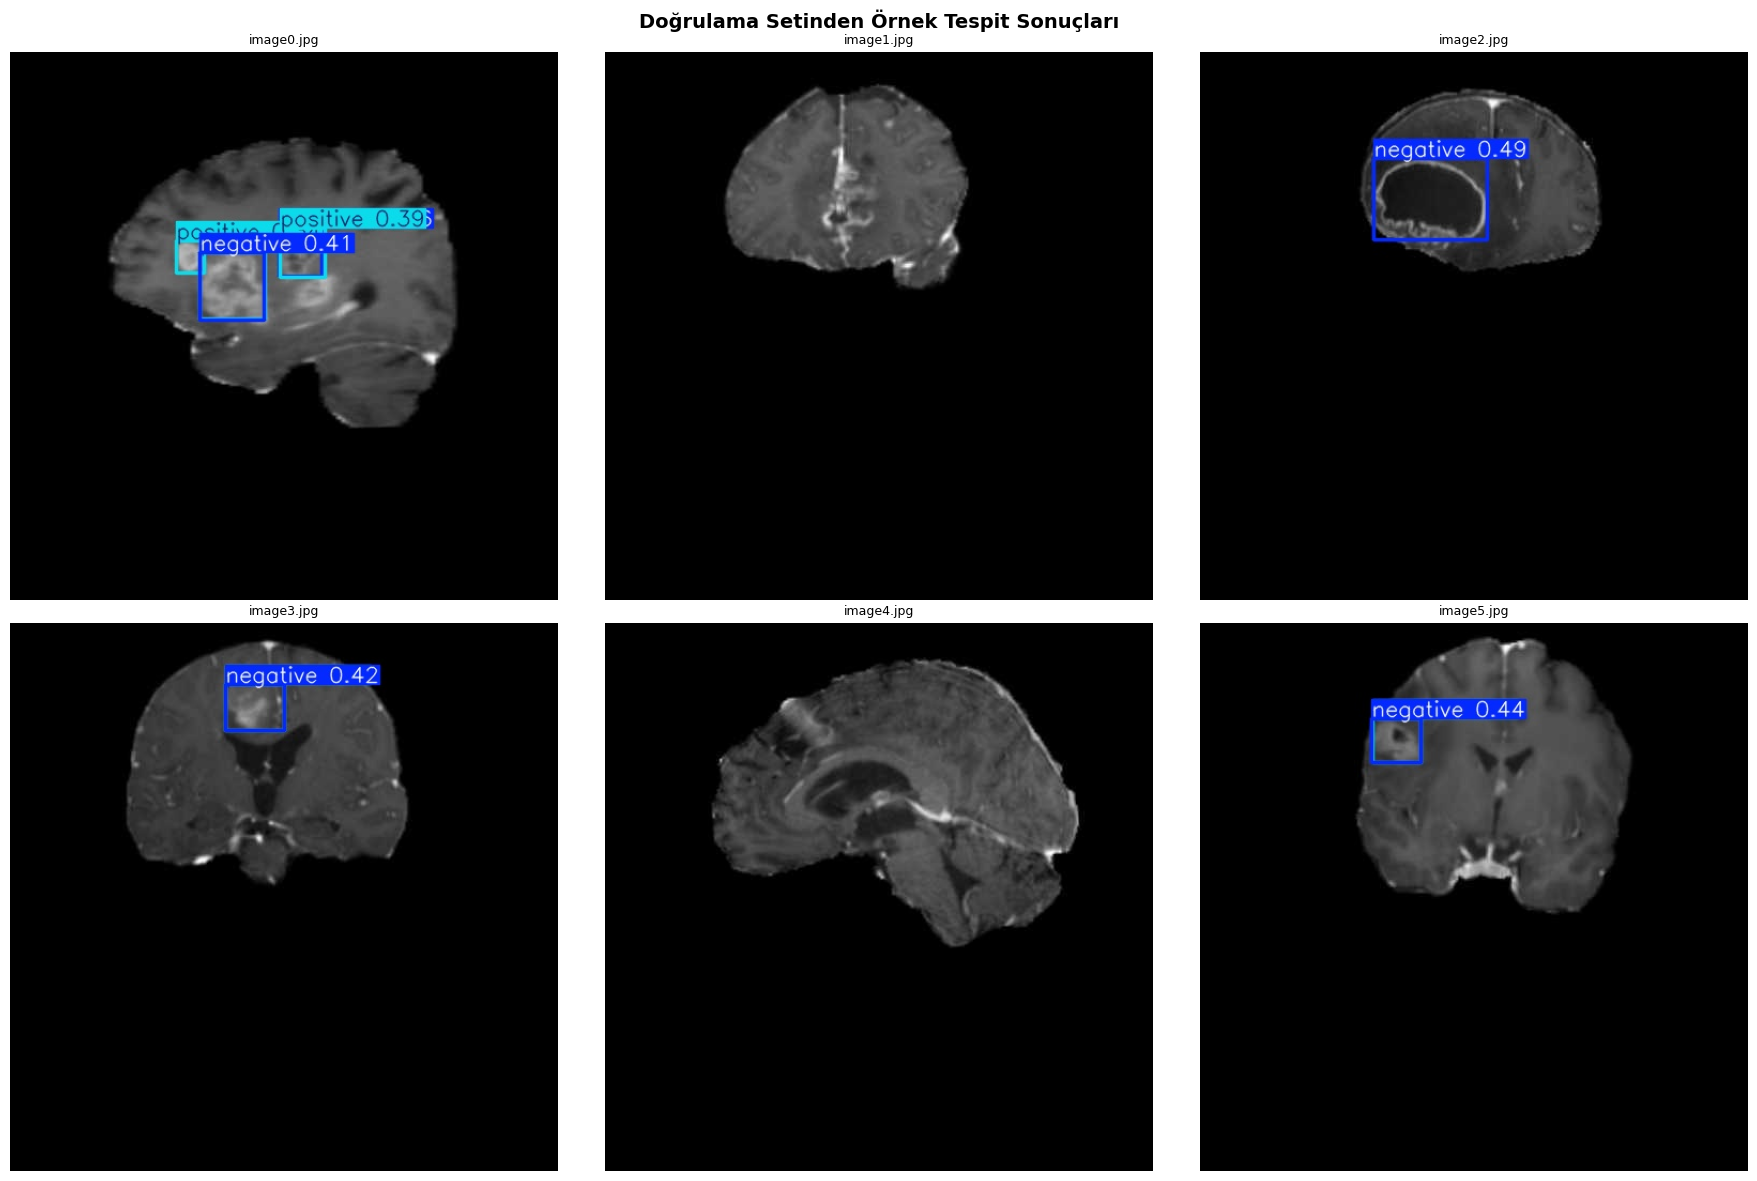

Kaydedildi: /content/tespit_sonuclari.png


In [20]:
val_images = sorted(glob.glob(os.path.join(actual_dataset_root, "images", "val", "*")))
sample_val = random.sample(val_images, min(6, len(val_images)))

predict_results = best_model.predict(
    source=sample_val,
    imgsz=640,
    conf=0.25,
    save=True,
    project="/content/runs",
    name="brain_tumor_predictions",
    exist_ok=True,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Doğrulama Setinden Örnek Tespit Sonuçları", fontsize=14, fontweight="bold")

pred_dir = "/content/runs/brain_tumor_predictions"
pred_images = sorted(glob.glob(os.path.join(pred_dir, "*.jpg")))

for ax, img_path in zip(axes.flat, pred_images[:6]):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path), fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("/content/tespit_sonuclari.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi: /content/tespit_sonuclari.png")

---
## Adım 12 — Eğitim Loglarının Detaylı Analizi

Eğitim sırasındaki loss ve metrik değerlerinin epoch bazlı grafiklerini çiziyoruz.

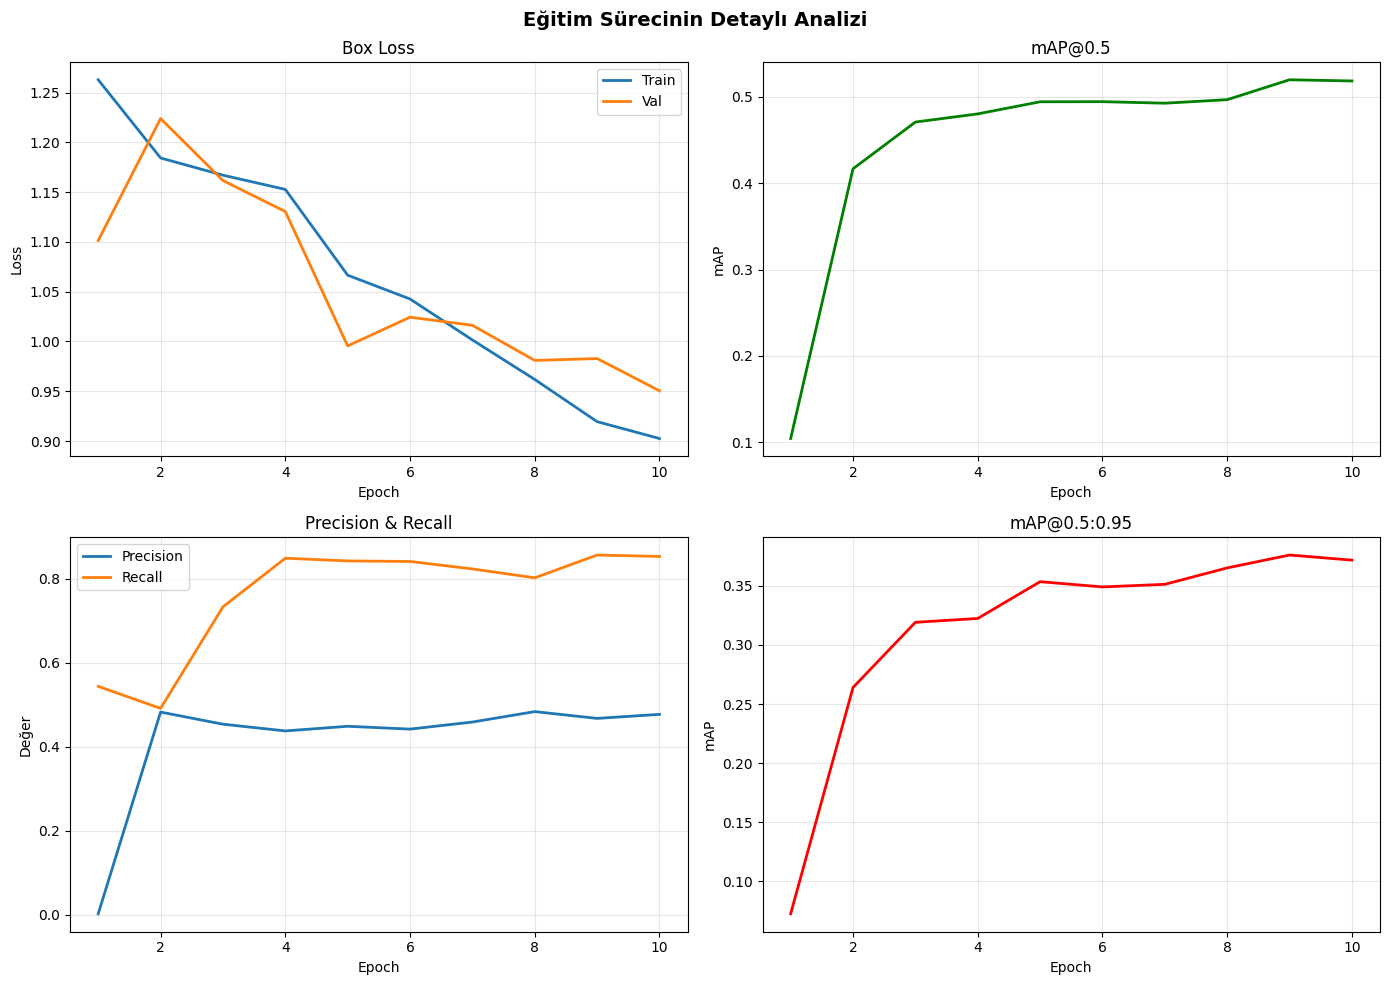

Kaydedildi: /content/egitim_analizi.png


In [21]:
csv_path = os.path.join(TRAIN_DIR, "results.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Eğitim Sürecinin Detaylı Analizi", fontsize=14, fontweight="bold")

    # Box Loss
    ax = axes[0, 0]
    if "train/box_loss" in df.columns:
        ax.plot(df["epoch"], df["train/box_loss"], label="Train", linewidth=2)
    if "val/box_loss" in df.columns:
        ax.plot(df["epoch"], df["val/box_loss"], label="Val", linewidth=2)
    ax.set_title("Box Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # mAP@0.5
    ax = axes[0, 1]
    if "metrics/mAP50(B)" in df.columns:
        ax.plot(df["epoch"], df["metrics/mAP50(B)"], color="green", linewidth=2)
    ax.set_title("mAP@0.5")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP")
    ax.grid(True, alpha=0.3)

    # Precision & Recall
    ax = axes[1, 0]
    if "metrics/precision(B)" in df.columns:
        ax.plot(df["epoch"], df["metrics/precision(B)"], label="Precision", linewidth=2)
    if "metrics/recall(B)" in df.columns:
        ax.plot(df["epoch"], df["metrics/recall(B)"], label="Recall", linewidth=2)
    ax.set_title("Precision & Recall")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Değer")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # mAP@0.5:0.95
    ax = axes[1, 1]
    if "metrics/mAP50-95(B)" in df.columns:
        ax.plot(df["epoch"], df["metrics/mAP50-95(B)"], color="red", linewidth=2)
    ax.set_title("mAP@0.5:0.95")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/content/egitim_analizi.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Kaydedildi: /content/egitim_analizi.png")
else:
    print("results.csv bulunamadı.")

---
## Adım 13 — Sonuç Özet Tablosu

Tüm değerlendirme metriklerini tek bir tabloda özetliyoruz.

In [22]:
import json

summary = {
    "Model": "YOLOv8n (nano)",
    "Ön-eğitimli Ağırlıklar": "yolov8n.pt (COCO)",
    "Epoch": 50,
    "Görüntü Boyutu": 640,
    "Batch Boyutu": 16,
    "Eğitim Görüntüsü": 893,
    "Doğrulama Görüntüsü": 223,
    "mAP@0.5": f"{val_results.box.map50:.4f}",
    "mAP@0.5:0.95": f"{val_results.box.map:.4f}",
    "Precision": f"{val_results.box.mp:.4f}",
    "Recall": f"{val_results.box.mr:.4f}",
}

try:
    summary["Accuracy"] = f"{accuracy:.4f}"
except NameError:
    summary["Accuracy"] = "(Confusion matrix'ten hesaplanacak)"

print("\n" + "=" * 60)
print("  PROJE SONUÇ ÖZETİ")
print("=" * 60)
for k, v in summary.items():
    print(f"  {k:<28s}: {v}")
print("=" * 60)

with open("/content/sonuc_ozet.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print("\nÖzet kaydedildi: /content/sonuc_ozet.json")


  PROJE SONUÇ ÖZETİ
  Model                       : YOLOv8n (nano)
  Ön-eğitimli Ağırlıklar      : yolov8n.pt (COCO)
  Epoch                       : 50
  Görüntü Boyutu              : 640
  Batch Boyutu                : 16
  Eğitim Görüntüsü            : 893
  Doğrulama Görüntüsü         : 223
  mAP@0.5                     : 0.5199
  mAP@0.5:0.95                : 0.3760
  Precision                   : 0.4674
  Recall                      : 0.8574
  Accuracy                    : 0.2420

Özet kaydedildi: /content/sonuc_ozet.json


---
## Adım 14 — Model ve Sonuçları İndirme

Eğitilmiş modeli ve çıktıları GitHub'a yüklemek için indiriyoruz.

In [23]:
import shutil
from google.colab import files

export_dir = "/content/export"
os.makedirs(export_dir, exist_ok=True)

shutil.copy2(os.path.join(TRAIN_DIR, "weights", "best.pt"), export_dir)

for fname in ["results.csv", "results.png", "confusion_matrix.png",
              "confusion_matrix_normalized.png", "F1_curve.png",
              "P_curve.png", "R_curve.png", "PR_curve.png"]:
    src = os.path.join(TRAIN_DIR, fname)
    if os.path.exists(src):
        shutil.copy2(src, export_dir)

for fname in ["ornek_goruntular.png", "tespit_sonuclari.png",
              "egitim_analizi.png", "sonuc_ozet.json"]:
    src = os.path.join("/content", fname)
    if os.path.exists(src):
        shutil.copy2(src, export_dir)

shutil.make_archive("/content/brain_tumor_results", "zip", export_dir)
print("\nExport içeriği:")
for f in sorted(os.listdir(export_dir)):
    size_mb = os.path.getsize(os.path.join(export_dir, f)) / (1024*1024)
    print(f"  {f} ({size_mb:.1f} MB)")

print("\nİndirme başlıyor...")
files.download("/content/brain_tumor_results.zip")


Export içeriği:
  best.pt (6.0 MB)
  confusion_matrix.png (0.1 MB)
  confusion_matrix_normalized.png (0.1 MB)
  egitim_analizi.png (0.2 MB)
  ornek_goruntular.png (0.0 MB)
  results.csv (0.0 MB)
  results.png (0.3 MB)
  sonuc_ozet.json (0.0 MB)
  tespit_sonuclari.png (0.6 MB)

İndirme başlıyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
## Sonuç ve Değerlendirme

Bu projede:

1. **Ultralytics Brain Tumor Detection** veri seti kullanılmıştır.
2. **YOLOv8n** modeli, ön-eğitimli COCO ağırlıkları ile **transfer öğrenme** yaklaşımıyla eğitilmiştir.
3. **Veri artırma** (augmentation) tekniklerinden yararlanılmıştır.
4. Model performansı **mAP@0.5**, **mAP@0.5:0.95**, **Precision**, **Recall**, **Accuracy** ve **Confusion Matrix** ile değerlendirilmiştir.
5. Tespit sonuçları örnek MR görüntüleri üzerinde **görselleştirilmiştir**.

### Öneriler
- Daha yüksek performans için **YOLOv8s** veya **YOLOv8m** gibi büyük modeller denenebilir.
- Epoch sayısı artırılabilir (100+).
- Hiperparametre optimizasyonu (learning rate, augmentation stratejileri) yapılabilir.
- Veri seti genişletilerek (daha fazla MR görüntüsü) modelin genelleme kapasitesi artırılabilir.